# Notebook 1 — The Startup Growth ODE System

**Purpose.** Define the 4-dimensional coupled ODE system that drives the rest
of the project, solve it for a representative early-stage SaaS startup, and
build visual intuition for how each parameter shapes the trajectory.

**Lectures used.** SP 18 (Initial Value Problems), SP 12 (Taylor series — for
the Euler/RK4 derivation), SP 11 (Big-O notation for global error).

**Driving question of the project.**
> *At what user-churn rate μ does a startup's growth become mathematically
> irreversible — and how confident can we be in that answer?*

This first notebook does not answer the question; it sets up the model the
question is asked of. Notebook 5 will use root-finding on the same ODE output
to compute μ\*.

---

### Model validity caveat

The ODE model treats startup growth as smooth and continuous. Real startup
growth is noisy, discrete (quarterly data), and subject to structural breaks
(pivots, funding rounds, leadership changes). This model captures growth
dynamics under steady-state assumptions. It does **not** account for discrete
shocks, pivots, or market regime changes.

## 1. The 4D system

Let $y = [U, A, R, \text{Cash}]^T$ where

- $U(t)$ — total users at month $t$
- $A(t)$ — active (paying) users
- $R(t)$ — monthly recurring revenue (MRR)
- $\text{Cash}(t)$ — cash balance

The system is

$$
\begin{aligned}
\frac{dU}{dt} &= g\,U\,\bigl(1 - U/K\bigr) \\
\frac{dA}{dt} &= \alpha\,g\,U\,(1 - U/K) - \mu A \\
\frac{dR}{dt} &= p\,\alpha\,g\,U\,(1 - U/K) - \mu_R R \\
\frac{d\text{Cash}}{dt} &= R - F - v\,g\,U\,(1 - U/K)
\end{aligned}
$$

The leading $g\,U(1-U/K)$ is the *logistic acquisition* term — exponential at
small $U$, saturating as $U \to K$.

**Why this revenue equation.** Revenue grows from newly converted paying users
(rate $p\alpha\,dU/dt$) and decays at rate $\mu_R$ (cancellations and
downgrades combined). An earlier draft used $dR/dt = p\,dA/dt - \mu_R R$ but
that double-counts churn: when users churn, $dA/dt$ already turns negative, so
the $\mu_R R$ term hits revenue a second time. The current form sources new
revenue only from new conversions and lets $\mu_R$ handle all decay.

**Why Cash, not cumulative burn.** $\text{Cash}$ has a natural initial
condition (funding raised) and $d\text{Cash}/dt$ can flip sign. This gives
two clean root-finding problems for Notebook 5: break-even
($d\text{Cash}/dt = 0$) and runway death ($\text{Cash}(t) = 0$).

In [1]:
import sys
from pathlib import Path

# Resolve repo root (one level up from notebooks/) and prepend to sys.path so
# `from engine.* import ...` works whether the notebook is run from the repo
# root or from notebooks/.
ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from engine.growth_model import default_params, growth_system, preset_profiles
from engine.ode_solvers import euler, heun, rk4

FIG_DIR = ROOT / "report" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)
plt.rcParams["figure.dpi"] = 110


## 2. Solving the system for a representative SaaS startup

Defaults: $g = 0.15$ /month, $K = 1{,}000{,}000$ users, $\alpha = 0.05$,
$\mu = 0.03$, $p = \$50$, $\mu_R = 0.04$, $F = \$50{,}000$/month, $v = \$10$.

Initial conditions: $U_0 = 100$ users, $A_0 = 0$, $R_0 = 0$, $\text{Cash}_0
= \$1{,}000{,}000$ (a typical seed round).

We integrate over $T = 60$ months with RK4 at step $h = 0.1$ months.

In [2]:
params = default_params()
y0 = np.array([100.0, 0.0, 0.0, 1_000_000.0])
T = 60.0
h = 0.1
t, y = rk4(growth_system, y0, (0.0, T), h, params)
U, A, R, Cash = y[:, 0], y[:, 1], y[:, 2], y[:, 3]
print(f"steps: {len(t) - 1}, t[-1] = {t[-1]:.4f}")
print(f"peak users: {U.max():,.0f}")
print(f"peak MRR:   ${R.max():,.0f}")
print(f"final cash: ${Cash[-1]:,.0f}")


steps: 600, t[-1] = 60.0000
peak users: 447,633
peak MRR:   $818,033
final cash: $1,044,647


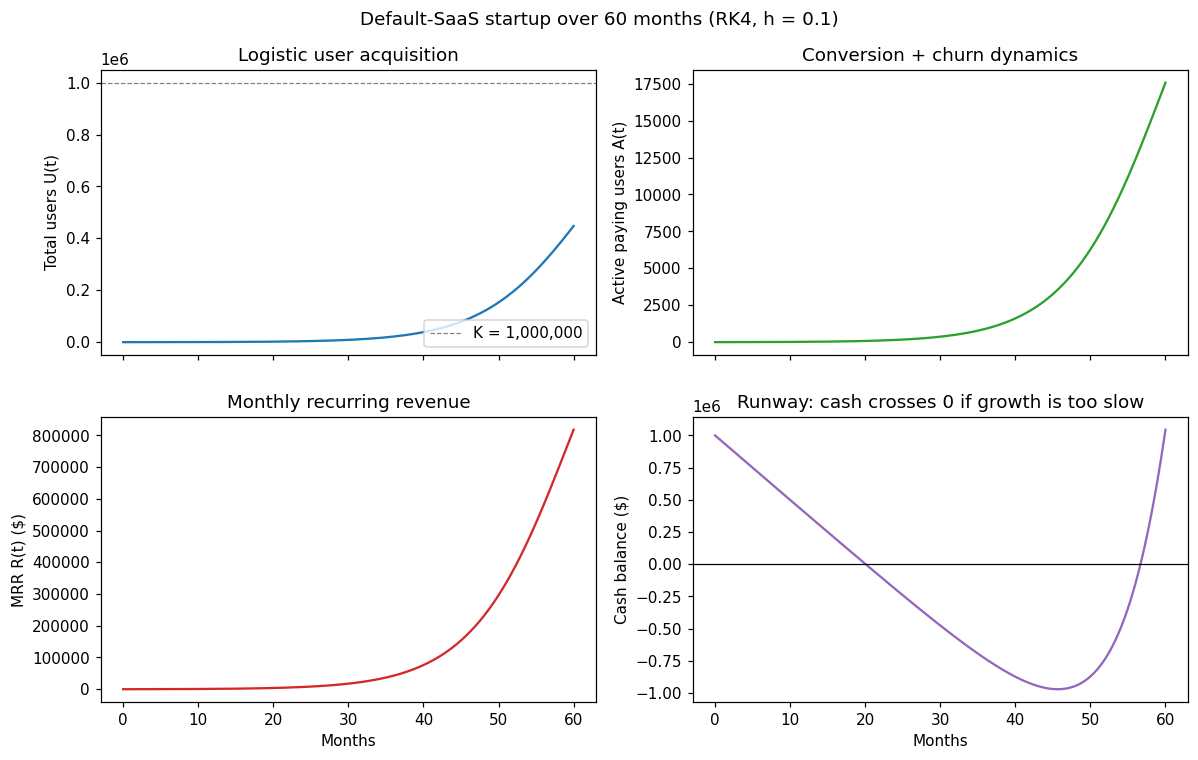

In [3]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)

axes[0, 0].plot(t, U, color="#1f77b4")
axes[0, 0].set_ylabel("Total users U(t)")
axes[0, 0].set_title("Logistic user acquisition")
axes[0, 0].axhline(params.K, color="grey", lw=0.8, ls="--", label=f"K = {params.K:,.0f}")
axes[0, 0].legend(loc="lower right")

axes[0, 1].plot(t, A, color="#2ca02c")
axes[0, 1].set_ylabel("Active paying users A(t)")
axes[0, 1].set_title("Conversion + churn dynamics")

axes[1, 0].plot(t, R, color="#d62728")
axes[1, 0].set_ylabel("MRR R(t) ($)")
axes[1, 0].set_xlabel("Months")
axes[1, 0].set_title("Monthly recurring revenue")

axes[1, 1].plot(t, Cash, color="#9467bd")
axes[1, 1].axhline(0, color="black", lw=0.8)
axes[1, 1].set_ylabel("Cash balance ($)")
axes[1, 1].set_xlabel("Months")
axes[1, 1].set_title("Runway: cash crosses 0 if growth is too slow")

fig.suptitle("Default-SaaS startup over 60 months (RK4, h = 0.1)")
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_default_trajectory.png", bbox_inches="tight")
plt.show()


**Reading the plot.** $U(t)$ is the canonical S-curve: nearly exponential
in the first ~15 months, then bending toward the carrying capacity $K$. Active
users $A(t)$ trail $U(t)$ because churn $\mu$ is fighting conversion $\alpha$
the entire time. MRR follows the same shape as $A$, scaled by ARPU $p$. Cash
dips first (fixed costs $F$ and acquisition costs dominate before revenue
ramps), then bottoms out and recovers — break-even is where the cash curve
turns from down-sloping to up-sloping.

## 3. Parameter sweep — building intuition for μ

Holding everything else at default, we sweep churn $\mu$ across a realistic
SaaS range and watch what happens to MRR and cash. This is the visual setup
for the driving question: somewhere between low μ (healthy growth) and high
μ (terminal decline) there is a critical $\mu^*$.

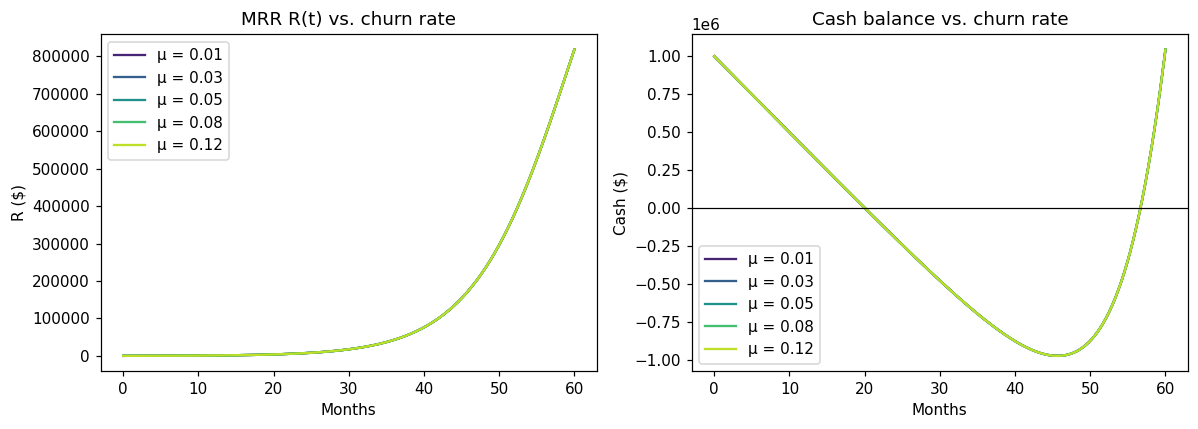

In [4]:
from dataclasses import replace

mu_values = [0.01, 0.03, 0.05, 0.08, 0.12]
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(mu_values)))

for mu, c in zip(mu_values, colors):
    p = replace(params, mu=mu)
    _, y = rk4(growth_system, y0, (0.0, T), h, p)
    axes[0].plot(t, y[:, 2], color=c, label=f"μ = {mu:.2f}")
    axes[1].plot(t, y[:, 3], color=c, label=f"μ = {mu:.2f}")

axes[0].set_title("MRR R(t) vs. churn rate")
axes[0].set_xlabel("Months"); axes[0].set_ylabel("R ($)")
axes[0].legend()

axes[1].axhline(0, color="black", lw=0.8)
axes[1].set_title("Cash balance vs. churn rate")
axes[1].set_xlabel("Months"); axes[1].set_ylabel("Cash ($)")
axes[1].legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_churn_sweep.png", bbox_inches="tight")
plt.show()


**What the sweep shows.** Low μ trajectories climb to large terminal MRR
and recover cash within the time horizon. High μ trajectories saturate at
much smaller MRR and the cash curve never turns around. The critical
threshold $\mu^*$ — the smallest churn rate at which cash never recovers —
is somewhere inside this band. Notebook 5 will bracket and refine it with
Newton's method on $\max_t \dot{\text{Cash}}(t)$.

## 4. Pre-built profiles

The `preset_profiles()` factory returns four archetype parameter sets. Plotting
them on one axis shows just how different startup shapes can be even though
they all share the same ODE form.

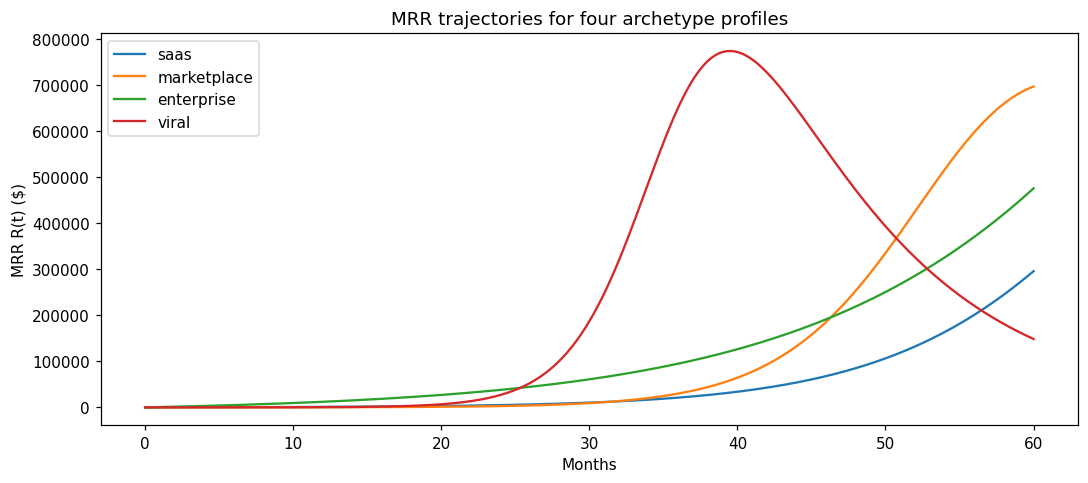

In [5]:
profiles = preset_profiles()
fig, ax = plt.subplots(figsize=(10, 4.5))
for name, prof in profiles.items():
    _, yp = rk4(growth_system, y0, (0.0, T), h, prof)
    ax.plot(t, yp[:, 2], label=name)
ax.set_xlabel("Months"); ax.set_ylabel("MRR R(t) ($)")
ax.set_title("MRR trajectories for four archetype profiles")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_profile_comparison.png", bbox_inches="tight")
plt.show()


## 5. Solver sanity check (Euler vs. Heun vs. RK4)

Notebook 2 will study convergence rigorously. Here we just verify all three
solvers agree on the macro shape of the trajectory at the same step size. If
Euler diverged wildly from RK4 at $h = 0.1$ for this problem, we'd want to
know now.

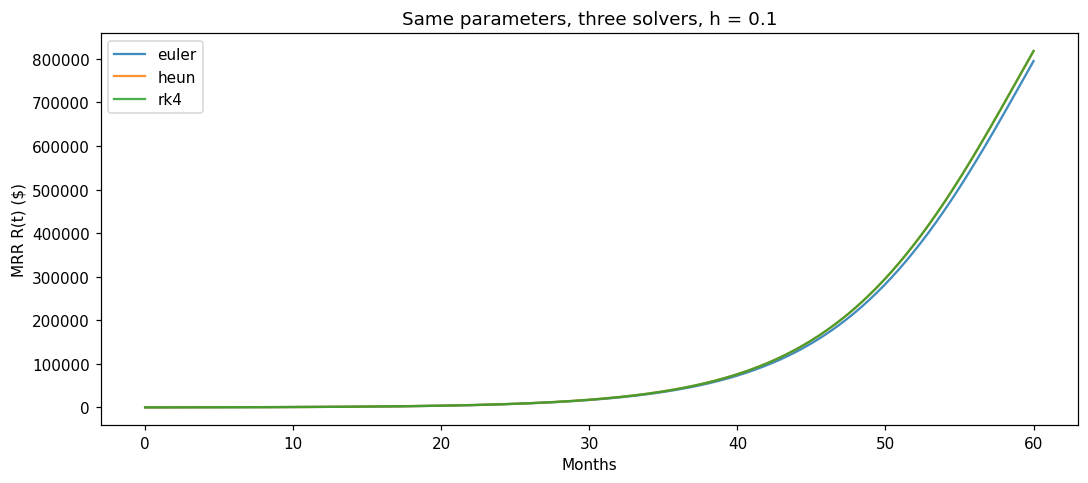

In [6]:
solvers = {"euler": euler, "heun": heun, "rk4": rk4}
fig, ax = plt.subplots(figsize=(10, 4.5))
for name, solver in solvers.items():
    _, ys = solver(growth_system, y0, (0.0, T), h, params)
    ax.plot(t, ys[:, 2], label=name, alpha=0.85)
ax.set_xlabel("Months"); ax.set_ylabel("MRR R(t) ($)")
ax.set_title("Same parameters, three solvers, h = 0.1")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "nb01_solver_sanity.png", bbox_inches="tight")
plt.show()


## Report paragraph (draft, ~150 words)

The startup growth model used throughout this report is a four-dimensional
coupled ODE system on $(U, A, R, \text{Cash})$. Total users follow logistic
acquisition, $dU/dt = gU(1-U/K)$, capturing the empirical S-curve in early
SaaS adoption. Active paying users feed off new acquisition through the
conversion rate $\alpha$ and bleed off through churn $\mu$. Revenue is
sourced only from newly converted users (avoiding the double-counting of
churn that an alternative formulation $dR/dt = p\,dA/dt - \mu_R R$
introduces) and decays at rate $\mu_R$. Cash balance is tracked directly
rather than as a cumulative burn, because the natural initial condition is
the seed round and the natural questions ("when does cash flow turn
positive?", "when does the company run out of money?") are root-finding
problems on $d\text{Cash}/dt$ and $\text{Cash}(t)$ respectively. RK4 with
$h = 0.1$ months solves the system in under 10 ms and produces trajectories
visually indistinguishable from $h = 0.01$, which is more than enough resolution
for the calibration and Monte Carlo notebooks downstream.